# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Nahdah Tsamarah Hasan
- **Email:** m277b4kx3225@bangkit.academy
- **ID Dicoding:** itsnah

## Menentukan Pertanyaan

1. Apakah faktor-faktor yang paling mempengaruhi jumlah penyewaan sepeda per hari?
2. Bagaimana pola pergerakan jumlah penyewaan sepeda dalam rentang 24 jam? Pada jam berapakah titik puncak dan titik terendah aktivitas penyewaan terjadi?
3. Faktor apa saja yang paling dominan mendorong tingginya jumlah penyewaan sepeda pada masing-masing periode waktu (Pagi, Siang, Sore, Malam)?

## Import Packages/Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler

## Data Wrangling

### Gathering Data

In [2]:
df_hour = pd.read_csv("data/hour.csv")
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [3]:
df_day = pd.read_csv("data/day.csv")
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
Pada kedua tabel diatas, ditampil 5 baris pertama dari file "hour.csv" dan "day.csv". Kedua file ini menampilkan data tentang sistem penyewaan sepeda per jam (untuk "hour.csv") dan per hari (untuk "day.csv") di Washington D.C.

**Penjelasan Header:**
* **instant**: Indeks dari setiap record.
* **dteday**: Tanggal dari record tersebut.
* **season**: Musim
  - 1: semi
  - 2: panas
  - 3: gugur
  - 4: dingin
* **yr**: Tahun data (0: 2011, 1: 2012).
* **mnth**: Bulan (1 sampai 12).
* **hr**: Jam (0 sampai 23).
* **holiday**: Apakah hari itu libur (0 bukan, 1 libur).
* **weekday**: Hari dalam minggu (0: Minggu, 6: Sabtu).
* **workingday**: Apakah hari kerja (0 bukan, 1 hari kerja).
* **weathersit**: Kondisi cuaca
  - 1: Cerah, sedikit awan, sebagian awan
  - 2: Berkabut, berawan
  - 3: Salju ringan, hujan ringan, atau badai ringan
  - 4: Hujan berat, salju, kabut, atau badai
* **temp**: Suhu yang dinormalisasi dalam Celsius, dibagi dengan 41 (nilai maksimum).
* **atemp**: Suhu yang dirasakan, dinormalisasi dalam Celsius, dibagi dengan 50 (nilai maksimum).
* **hum**: Kelembapan yang dinormalisasi, dibagi dengan 100 (nilai maksimum).
* **windspeed**: Kecepatan angin yang dinormalisasi, dibagi dengan 67 (nilai maksimum).
* **casual**: Jumlah penyewa kasual (bukan member).
* **registered**: Jumlah penyewa terdaftar (member).
* **cnt**: Jumlah total penyewaan sepeda (casual + registered).

### Assessing Data

#### Menilai Tabel `df_day`




In [4]:
df_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [5]:
print("Jumlah duplikasi: ", df_day.duplicated().sum())

df_day.describe()

Jumlah duplikasi:  0


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
Jumlah data pada df_day telah lengkap, tidak ada missing value dan duplikasi di dalamnya. Akan tetapi, terdapat kesalahan tipe data untuk kolom `dteday`. Kolom tersebut harusnya direpresentasikan sebagai tipe data datetime, bukan object.

#### Menilai Tabel `df_hour`




In [6]:
df_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [7]:
print("Jumlah duplikasi: ", df_hour.duplicated().sum())

df_hour.describe()

Jumlah duplikasi:  0


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
Jumlah data pada df_hour telah lengkap, tidak ada missing value dan duplikasi di dalamnya. Akan tetapi, terdapat kesalahan tipe data untuk kolom `dteday`. Kolom tersebut harusnya direpresentasikan sebagai tipe data datetime, bukan object.

### Cleaning Data

#### Memperbaiki Tipe Data Pada `df_day`



Kita ubah tipe kolom `dteday` menjadi datetime

In [8]:
datetime_columns = ["dteday"]

for column in datetime_columns:
  df_day[column] = pd.to_datetime(df_day[column])

In [9]:
df_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [10]:
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


#### Memperbaiki Tipe Data Pada `df_hour`

Kita ubah tipe kolom `dteday` menjadi datetime

In [11]:
datetime_columns = ["dteday"]

for column in datetime_columns:
  df_hour[column] = pd.to_datetime(df_hour[column])

In [12]:
df_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

In [13]:
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## Exploratory Data Analysis (EDA)

### Explore `df_day`

Pada tahap ini, kita akan membedah karakteristik data `df_day` berdasarkan dua kelompok utama: **Data Kategorikal** (Musim, Hari Libur, dll) dan **Data Numerik** (Suhu, Kelembaban, dll).

Tujuannya adalah **untuk memahami pola distribusi penyewaan sepeda** pada setiap variabel. Setelah eksplorasi individual selesai, kita akan melakukan analisis menggunakan **Correlation Matrix** (Heatmap) untuk memvalidasi dan **menentukan faktor mana yang paling dominan mempengaruhi jumlah penyewaan** sepeda (`cnt`) secara statistik.

#### Data Kategori

In [14]:
df_day.describe(include='all')

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


Berdasarkan rangkuman parameter statistik di atas, kita akan memperoleh informasi bahwa pada tahun 2011 sampai tahun 2012, jumlah penyewa sepeda dalam satu hari **paling sedikit sebanyak 22 orang** dan **paling banyak sebanyak 8714 orang** dengan standar deviasinya sebesar 1937.211452.

In [15]:
# EDA untuk faktor musim
df_day.groupby(by="season").agg({
    "cnt": ["max", "min", "mean", "std"]
})

cnt                                
         max   min         mean          std
season                                      
1       7836   431  2604.132597  1399.942119
2       8362   795  4992.331522  1695.977235
3       8714  1115  5644.303191  1459.800381
4       8555    22  4728.162921  1699.615261

Berdasarkan output tersebut, **musim gugur Musim Gugur (Season 3)** adalah **waktu yang paling populer** untuk menyewa sepeda. Dengan rata-rata penyewaan sepeda harian yang tertinggi terjadi pada musim gugur (sekitar 5.644 sepeda per hari). Pada musim semi (Season 1), rata-rata penyewaan sepeda harian hanya sekitar 2.604 penyewaan per hari. Hal ini menunjukan bahwa **musim semi kurang diminati** untuk aktivitas bersepeda. Jumlah **penyewaan** sepeda dalam sehari **paling minimum** terjadi pada **musim dingin (Season 4)**, yaitu hanya 22 sepeda dalam sehari. Sedangkan jumlah penyewaan sepeda dalam sehari **paling maksimum** terjadi pada **musim gugur**, yaitu 8.714 sepeda dalam sehari.

In [16]:
# EDA untuk faktor holiday
df_day.groupby(by="holiday").agg({
    "cnt": ["max", "min", "mean", "std"]
})

cnt                                
          max   min         mean          std
holiday                                      
0        8714    22  4527.104225  1929.013947
1        7403  1000  3735.000000  2103.350660

Berdasarkan output tersebut, **waktu yang paling populer** untuk menyewa sepeda adalah **hari biasa** dengan rata-rata penyewaan sepeda sekitar 4.527 sepeda per hari, sedangkan hari libur hanya sekitar 3.735 sepeda per hari. **Penyewaan** sepeda **pada hari libur** cenderung **lebih fluktuatif** dengan standar deviasi lebih tinggi sebesar 2.103 dibandingkan hari biasa. 

In [17]:
# EDA untuk faktor weekday
df_day.groupby(by="weekday").agg({
    "cnt": ["max", "min", "mean", "std"]
})

cnt                                
          max   min         mean          std
weekday                                      
0        8227   605  4228.828571  1872.496629
1        7525    22  4338.123810  1793.074013
2        7767   683  4510.663462  1826.911642
3        8173   441  4548.538462  2038.095884
4        7804   431  4667.259615  1939.433317
5        8362  1167  4690.288462  1874.624870
6        8714   627  4550.542857  2196.693009

Berdasarkan output tersebut, **waktu yang paling populer** untuk menyewa sepeda adalah **Hari Jumat (Weekday 5)** dengan rata-rata penyewaan sekitar 4.690 sepeda per hari. Output ini sesuai dengan insight yang kita dapat sebelumnnya bahwa jumlah penyewa pada hari biasa (yang mana hari Jumat merupakan hari biasa) lebih banyak daripada jumlah penyewa pada hari libur. Sebaliknya, penyewaan sepeda pada **Hari Minggu (Weekday 0)** memiliki **rata-rata penyewaan terendah** yaitu sekitar 4.228 per hari.

In [18]:
# EDA untuk faktor workingday
df_day.groupby(by="workingday").agg({
    "cnt": ["max", "min", "mean", "std"]
})

cnt                               
             max  min         mean          std
workingday                                     
0           8714  605  4330.168831  2052.141245
1           8362   22  4584.820000  1878.415583

Berdasarkan output tersebut, **waktu yang paling populer** untuk menyewa sepeda adalah **hari kerja (Workingday 1)** dengan rata-rata penyewaan sepeda harian sekitar 4.584 sepeda per hari. Output ini sesuai dengan insight yang kita dapat sebelumnya bahwa jumlah penyewa pada hari biasa (yang mana hari kerja merupakan hari biasa) lebih banyak daripada jumlah penyewa pada hari libur. 

In [19]:
# EDA untuk faktor cuaca
df_day.groupby(by="weathersit").agg({
    "cnt": ["max", "min", "mean", "std"]
})

cnt                               
             max  min         mean          std
weathersit                                     
1           8714  431  4876.786177  1879.483989
2           8362  605  4035.862348  1809.109918
3           4639   22  1803.285714  1240.284449

Berdasarkan output tersebut, pada **cuaca yang cerah dan sedikit berawan** jumlah rata-rata penyewaan sepeda perharinya mencapai 4.876 sepeda per hari, ini merupakan cuaca dengan **jumlah rata-rata penyewaan tertinggi dalam sehari**. Sedangkan pada cuaca dengan salju ringan, hujan ringan, atau badai ringan jumlah rata-rata penyewaan sepeda perharinya hanya mencapai 1.803 sepeda per hari dan pada cuaca dengan hujan berat, salju, kabut, atau badai tidak ada yang menyewa sepeda. Jumlah penyewaan sepeda dalam sehari paling maksimum terjadi di cuaca yang cerah dan sedikit berawan, yaitu sebanyak 8.714 sepeda.

#### Data Numerik

In [20]:
# EDA untuk faktor suhu
df_day[['temp', 'cnt']].corr()

,temp,cnt
temp,1.000000,0.627494
cnt,0.627494,1.000000


Korelasi antara suhu dan jumlah sepeda yang di sewa per harinya adalah 0.627494. Ini menunjukkan korelasi positif yang cukup kuat antara suhu dan jumlah penyewaan sepeda. Artinya, **ketika suhu naik, jumlah penyewaan sepeda juga cenderung meningkat**. Orang cenderung lebih suka bersepeda saat suhu lebih nyaman atau hangat.

In [21]:
# Korelasi antar variabel numerik
df_day[['atemp', 'cnt']].corr()

,atemp,cnt
atemp,1.000000,0.631066
cnt,0.631066,1.000000


Korelasi antara suhu yang dirasakan dan jumlah sepeda yang di sewa per harinya adalah 0.631066. Ini menunjukkan korelasi positif yang cukup kuat antara suhu yang dirasakan dan jumlah penyewaan sepeda. Artinya, **ketika suhu yang dirasakan (atemp) naik, jumlah penyewaan sepeda juga cenderung meningkat**. Orang cenderung lebih suka bersepeda saat suhu lebih nyaman atau hangat.

In [22]:
# EDA untuk faktor kelembapan
df_day[['hum', 'cnt']].corr()

,hum,cnt
hum,1.000000,-0.100659
cnt,-0.100659,1.000000


Korelasi antara kelembapan dan jumlah sepeda yang di sewa per harinya adalah -0.100659. Ini menunjukkan korelasi negatif yang sangat lemah sehingga dapat disimpulkan bahwa **kelembapan tidak terlalu mempengaruhi jumlah penyewaan sepeda**, walaupun ada sedikit kecenderungan bahwa ketika kelembapan menurun, jumlah penyewaan sepeda cenderung meningkat.

In [23]:
# EDA untuk faktor kecepatan angin
df_day[['windspeed', 'cnt']].corr()

,windspeed,cnt
windspeed,1.000000,-0.234545
cnt,-0.234545,1.000000


Korelasi antara kecepatan angin dan jumlah sepeda yang di sewa per harinya adalah -0.234545. Ini menunjukkan korelasi negatif lemah antara kecepatan angin dan penyewaan sepeda. **Ketika angin semakin kencang, orang cenderung lebih sedikit menyewa sepeda**. Namun, seperti yang kita lihat, **efeknya masih lemah**, yang berarti kecepatan angin bukan satu-satunya faktor yang menentukan keputusan penyewaan.

#### Heatmap

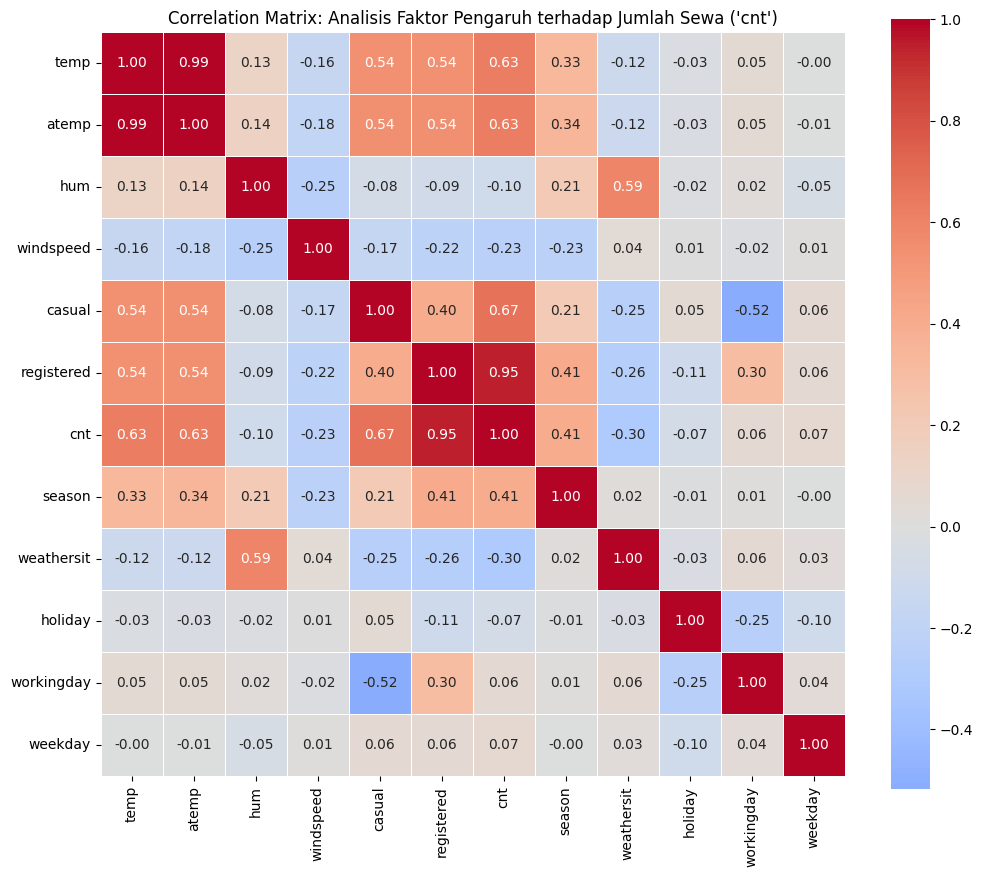

In [24]:
plt.figure(figsize=(12, 10))
correlation_matrix = df_day[['temp', 'atemp', 'hum', 'windspeed', 
                             'casual', 'registered', 'cnt', 
                             'season', 'weathersit', 'holiday', 'workingday', 'weekday']].corr()

sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    center=0,
    linewidths=.5,
    square=True
)
plt.title("Correlation Matrix: Analisis Faktor Pengaruh terhadap Jumlah Sewa ('cnt')")
plt.show()

KESIMPULAN FAKTOR PENGARUH:

Berdasarkan analisis Correlation Matrix di atas, faktor-faktor yang paling **mempengaruhi jumlah penyewaan** sepeda (`cnt`) adalah:

1. **Suhu (`atemp` & `temp`)**: Memiliki korelasi positif terkuat (0.63) dan merupakan faktor penentu utama. Semakin hangat suhu, semakin tinggi minat menyewa sepeda.
2. **Musim (`season`)**: Memiliki korelasi positif dan merupakan faktor terkuat kedua (0.41). Siklus musim memiliki dampak signifikan terhadap pola penyewaan sepeda. 
3. **Kondisi Cuaca (`weathersit`)**: Memiliki korelasi negatif (-0.30). Artinya, semakin buruk cuaca (angka makin besar), penyewaan makin turun.
4. **Kecepatan Angin (`windspeed`)**: Memiliki korelasi negatif (-0.23).

**Faktor yang tidak berpengaruh:** 

**Faktor Kelembapan (`hum`)** dan variabel kalender seperti **Hari Libur (`holiday`), Hari Kerja (`workingday`), dan Hari dalam Minggu (`weekday`**) memiliki korelasi yang sangat lemah (mendekati 0). Artinya, secara rata-rata tahunan, status hari tidak terlalu mempengaruhi keputusan penyewaan dibandingkan faktor lingkungan.

### Explore `df_hour`

In [25]:
df_hour.describe(include='all')

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


Berdasarkan rangkuman parameter statistik di atas, kita akan memperoleh informasi bahwa ada tahun 2011 sampai tahun 2012, **jumlah penyewa sepeda dalam satu jam paling sedikit sebanyak 1 orang dan paling banyak sebanyak 977 orang**, dengan standar deviasinya sebesar 181.387599.

In [26]:
# Grouping data berdasarkan jam
df_hour.groupby('hr')['cnt'].agg(['mean', 'max', 'min', 'std'])

,mean,max,min,std
hr,,,,
0,53.898072,283,2,42.307910
1,33.375691,168,1,33.538727
2,22.869930,132,1,26.578642
3,11.727403,79,1,13.239190
4,6.352941,28,1,4.143818
5,19.889819,66,1,13.200765
6,76.044138,213,1,55.084348
7,212.064649,596,1,161.441936
8,359.011004,839,5,235.189285


Penyewaan sepeda per jamnya paling tinggi terjadi pada jam 17:00 (jam 5 sore) dengan rata-rata penyewaan 461 sepeda per jam. Pada jam 18:00 (jam 6 sore) rata-rata penyewaan sepeda juga sangat tinggi, yaitu 425 sepeda per jam. Pada **pagi hari, puncaknya jam 8:00** (jam 8 pagi) juga menunjukkan **penyewaan sepeda yang tinggi** dengan rata-rata 359 sepeda per jam. Selain itu, jam 16:00 (jam 4 sore) dan jam 19:00 (jam 7 malam) juga menunjukkan rata-rata penyewaan yang tinggi, yaitu 311 sepeda per jam. Jadi, **sore hari antara jam 4 hingga 7 adalah waktu puncak penyewaan sepeda**.  **Penyewaan paling rendah** terjadi antara **jam 3 pagi hingga jam 5 pagi**. Pada jam 5 pagi, rata-rata penyewaan sepeda hanya sekitar 19 sepeda per jam. Pada jam 4 pagi, rata-rata penyewaan sepeda hanya sekitar 6 sepeda per jam. Dan pada jam 3 pagi hanya sekitar 11 sepeda per jam. Ini masuk akal karena pada jam tersebut kebanyakan orang tidak beraktivitas di luar. Sedangkan pagi hari dan sore hari adalah jam-jam ketika banyak orang melakukan aktivitas di luar.

## Visualization & Explanatory Analysis

> Faktor cuaca (`weathersit`) dan musim (`season`) terbukti memiliki pengaruh terbesar terhadap jumlah penyewaan sepeda per hari. Kondisi cuaca yang baik dan musim gugur mendorong peningkatan penyewaan, sementara hari libur menunjukkan sedikit penurunan penyewaan. Di sisi lain, hari kerja dan hari dalam seminggu (`weekday`) tidak memiliki dampak yang signifikan terhadap pola penyewaan sepeda.

> Data menunjukkan bahwa penyewaan sepeda mencapai puncaknya pada jam 17:00 hingga 18:00, yang menunjukkan peningkatan aktivitas pada sore hari. Sedangkan jam 1 hingga 5 pagi adalah periode paling sepi dengan aktivitas penyewaan yang sangat rendah.

### Apakah faktor-faktor yang paling mempengaruhi jumlah penyewaan sepeda per hari?

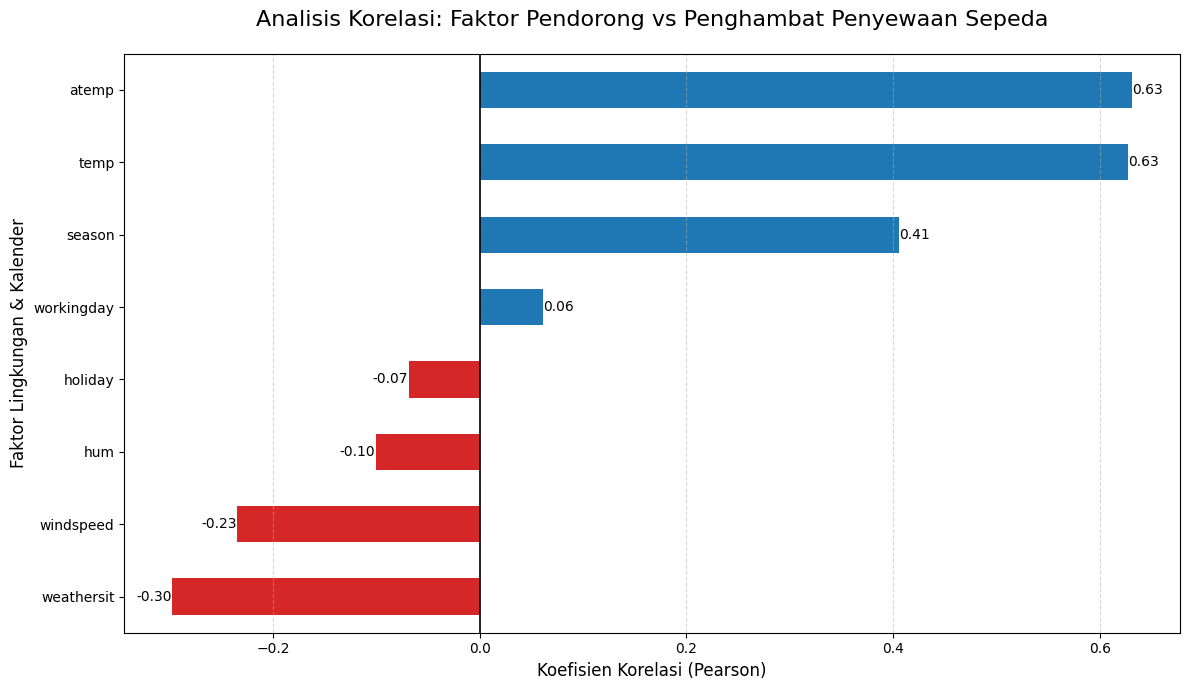

In [27]:
fig, ax = plt.subplots(figsize=(12, 7))

# Data korelasi
correlation_data = df_day[['temp', 'atemp', 'hum', 'windspeed',
                           'season', 'weathersit', 'holiday', 'workingday', 'cnt']].corr()['cnt']

correlation_data = correlation_data.drop('cnt')

correlation_data = correlation_data.sort_values(ascending=True)

colors = ['#d62728' if x < 0 else '#1f77b4' for x in correlation_data]

correlation_data.plot(kind='barh', color=colors, ax=ax)

ax.set_title("Analisis Korelasi: Faktor Pendorong vs Penghambat Penyewaan Sepeda", fontsize=16, pad=20)
ax.set_xlabel("Koefisien Korelasi (Pearson)", fontsize=12)
ax.set_ylabel("Faktor Lingkungan & Kalender", fontsize=12)
ax.axvline(x=0, color='black', linestyle='-', linewidth=1.2) # Garis tengah tegas
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Menampilkan label angka di ujung bar
for index, value in enumerate(correlation_data):
    # Logika posisi label (biar rapi tidak nabrak bar)
    if value > 0:
        ax.text(value, index, f'{value:.2f}', va='center', fontsize=10, color='black')
    else:
        ax.text(value - 0.035, index, f'{value:.2f}', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

Berdasarkan grafik Diverging Bar Chart di atas, kita dapat memetakan **faktor-faktor yang mempengaruhi jumlah penyewaan sepeda** (`cnt`) menjadi dua kelompok utama, yaitu Faktor Pendorong (Positif) dan Faktor Penghambat (Negatif). Berikut adalah hasil analisisnya:

1. **Faktor Pendorong Utama** (Positive Drivers):

    - **`atemp` (Suhu yang dirasakan) & `temp` (Suhu)**: Keduanya memiliki korelasi positif yang sangat kuat (0.63). Maka, semakin hangat suhu udara (hingga batas kenyamanan tertentu), semakin tinggi minat masyarakat untuk bersepeda. Orang cenderung menghindari bersepeda saat suhu terlalu dingin.

    - **`season` (Musim)**: Memiliki korelasi positif moderat (0.41). Hal ini selaras dengan faktor suhu, di mana musim-musim yang lebih hangat (seperti Gugur dan Panas) mencatat volume penyewaan yang jauh lebih tinggi dibandingkan musim Dingin atau Semi awal.

2. **Faktor Penghambat Utama** (Negative Blockers):

    - **`weathersit` (Kondisi Cuaca)**: Memiliki korelasi negatif sebesar -0.30. Karena skala `weathersit` semakin besar artinya cuaca semakin buruk (1=Cerah, sedikit awan, sebagian awan, sedangkan 4=Hujan berat, salju, kabut, atau badai), korelasi negatif ini bermakna bahwa kondisi cuaca buruk adalah hambatan nyata bagi penyewaan sepeda.

    - **`windspeed` (Kecepatan Angin)**: Memiliki korelasi negatif -0.23. Angin kencang terbukti mengurangi kenyamanan dan keamanan bersepeda, sehingga menurunkan jumlah penyewaan, meskipun dampaknya tidak sefatal hujan.

    - **`hum` (Kelembapan)**: Memiliki korelasi negatif lemah (-0.10). Kelembapan tinggi sedikit mengurangi kenyamanan, namun bukan faktor penentu utama ('deal-breaker') bagi pengguna.

3. **Faktor Netral** (Non-Influential): 

    Faktor **`workingday` (Hari Kerja), `weekday` (Hari dalam minggu), dan `holiday` (Hari Libur)** memiliki nilai korelasi yang sangat kecil (mendekati 0, antara -0.07 hingga 0.06).

Hal ini menunjukkan bahwa sistem penyewaan sepeda ini memiliki tingkat resiliensi permintaan yang tinggi. Sepeda tetap dibutuhkan baik di hari kerja  maupun di hari libur. Permintaan tidak anjlok hanya karena status hari, melainkan lebih bergantung pada apakah cuacanya mendukung atau tidak.

### Bagaimana pola pergerakan jumlah penyewaan sepeda dalam rentang 24 jam? Pada jam berapakah titik puncak dan titik terendah aktivitas penyewaan terjadi?

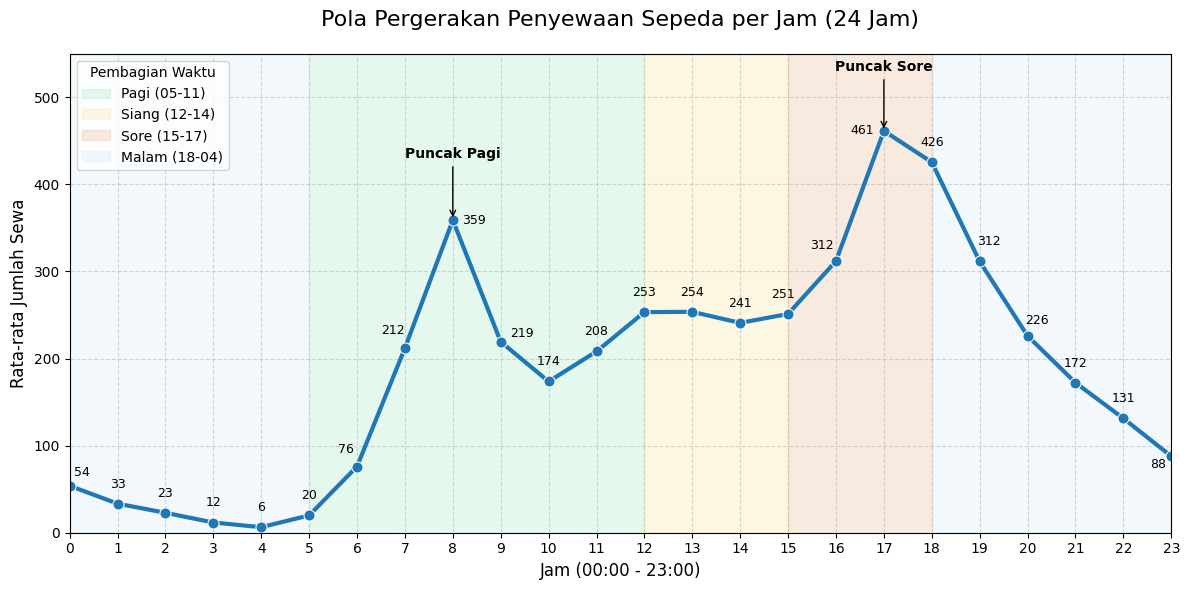

In [28]:
# --- 1. PEMBAGIAN WAKTU ---
def get_time_segment(hr):
    if 5 <= hr <= 11:
        return 'Pagi (05:00 - 11:59)'
    elif 12 <= hr <= 14:
        return 'Siang (12:00 - 14:59)'
    elif 15 <= hr <= 17:
        return 'Sore (15:00 - 17:59)'
    else:
        return 'Malam (18:00 - 04:59)'

df_hour['time_segment'] = df_hour['hr'].apply(get_time_segment)
hourly_data = df_hour.groupby('hr')[['cnt']].mean()

# --- 2. VISUALISASI  ---
# Variabel Kontrol untuk Dashboard 
show_values = True 

plt.figure(figsize=(12, 6))

# Plot Line Chart
sns.lineplot(
    data=hourly_data, 
    x=hourly_data.index, 
    y='cnt', 
    marker='o', 
    markersize=8,
    color='#1f77b4', 
    linewidth=3
)

# Background Color (Span)
plt.axvspan(5, 12, color='#abebc6', alpha=0.3, label='Pagi (05-11)')
plt.axvspan(12, 15, color='#f9e79f', alpha=0.3, label='Siang (12-14)')
plt.axvspan(15, 18, color='#edbb99', alpha=0.3, label='Sore (15-17)')
plt.axvspan(18, 23.5, color='#d6eaf8', alpha=0.3, label='Malam (18-04)') # 23.5 biar tembus kanan
plt.axvspan(-0.5, 5, color='#d6eaf8', alpha=0.3) # -0.5 biar tembus kiri

# ANNOTASI PUNCAK
# Puncak Pagi
plt.annotate('Puncak Pagi', xy=(8, 359), xytext=(8, 430),
             arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle="arc3"), 
             ha='center', fontsize=10, fontweight='bold')

# Puncak Sore
plt.annotate('Puncak Sore', xy=(17, 461), xytext=(17, 530),
             arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle="arc3"), 
             ha='center', fontsize=10, fontweight='bold')

# MENAMPILKAN ANGKA
if show_values:
    for x, y in zip(hourly_data.index, hourly_data['cnt']):
        label = f"{y:.0f}"
        
        # Posisi Label Khusus
        if x == 0: 
            plt.text(x + 0.1, y + 15, label, ha='left', va='center', fontsize=9, color='black')
        elif x == 23:
            plt.text(x - 0.1, y - 10, label, ha='right', va='center', fontsize=9, color='black')
        elif x == 8: # Puncak Pagi
            plt.text(x + 0.2, y, label, ha='left', va='center', fontsize=9, color='black')
        elif x == 17: # Puncak Sore
            plt.text(x - 0.7, y, label, ha='left', va='center', fontsize=9, color='black')
        elif x == 6:
            plt.text(x - 0.4, y + 20, label, ha='left', va='center', fontsize=9, color='black')
        elif x == 7:
            plt.text(x - 0.5, y + 20, label, ha='left', va='center', fontsize=9, color='black')
        elif x == 9:
            plt.text(x + 0.2, y + 10, label, ha='left', va='center', fontsize=9, color='black')
        elif x == 15:
            plt.text(x - 0.1, y + 15, label, ha='center', va='bottom', fontsize=9, color='black')
        elif x == 16:
            plt.text(x - 0.3, y + 10, label, ha='center', va='bottom', fontsize=9, color='black')
        elif x == 19:
            plt.text(x + 0.2, y + 15, label, ha='center', va='bottom', fontsize=9, color='black')
        elif x == 20:
            plt.text(x + 0.2, y + 10, label, ha='center', va='bottom', fontsize=9, color='black')
        else:
            plt.text(x, y + 15, label, ha='center', va='bottom', fontsize=9, color='black')

# SETUP AXIS
plt.xlim(0, 23) 
plt.ylim(0, 550)
plt.xticks(range(0, 24))

# Dekorasi
plt.title("Pola Pergerakan Penyewaan Sepeda per Jam (24 Jam)", fontsize=16, pad=20)
plt.xlabel("Jam (00:00 - 23:00)", fontsize=12)
plt.ylabel("Rata-rata Jumlah Sewa", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', title='Pembagian Waktu', frameon=True)

plt.tight_layout()
plt.show()

Grafik di atas memperlihatkan pola aktivitas pengguna yang sangat jelas membentuk dua puncak utama dalam siklus 24 jam:

1. **Puncak Aktivitas Pagi dan Sore**

    Aktivitas penyewaan melonjak tajam pada pagi hari tepat **pukul 08.00** dengan rata-rata 359 penyewaan. Setelah itu angka menurun, lalu kembali naik drastis pada sore hari. **Puncak tertinggi** harian terjadi pada **pukul 17.00** dengan rata-rata 461 penyewaan, dan angka ini masih bertahan cukup tinggi di pukul 18.00 (426 penyewaan).

2. Stabilitas di Siang Hari
    
    Di antara dua waktu sibuk tersebut, yaitu pada rentang **pukul 12.00 hingga 15.00**, jumlah penyewaan terlihat **stabil** mendatar. Rata-rata penyewaan di jam-jam ini konsisten berada di kisaran angka 240 hingga 250 unit, tidak naik drastis tapi juga tidak sepi.

3. Waktu Istirahat 

    **Penyewaan** sepeda benar-benar **minim pada dini hari**. Aktivitas mulai **turun** drastis **setelah jam 20.00** dan menyentuh **titik terendah** pada **pukul 04.00 pagi** yang hanya mencatat rata-rata 6 penyewaan. Angka baru mulai merangkak **naik** kembali saat memasuki **pukul 06.00 pagi**.

### Faktor apa saja yang paling dominan mendorong tingginya jumlah penyewaan sepeda pada masing-masing periode waktu (Pagi, Siang, Sore, Malam)?

In [29]:
from sklearn.cluster import KMeans

# --- 1. PERSIAPAN CLUSTERING PER SEGMEN ---
# Dictionary untuk menyimpan label kategori setiap jam
hour_label_map = {}

# Daftar urutan segmen 
segments = ['Pagi (05:00 - 11:59)', 'Siang (12:00 - 14:59)', 
            'Sore (15:00 - 17:59)', 'Malam (18:00 - 04:59)']

print("HASIL CLUSTERING JAM (HIGH/MEDIUM/LOW DEMAND):")
print("="*50)

# Loop untuk setiap segmen waktu
for segment in segments:
    # 1. Ambil data jam yang termasuk dalam segmen ini
    segment_data = df_hour[df_hour['time_segment'] == segment]
    
    # 2. Hitung rata-rata penyewaan per jam di segmen ini
    hourly_stats = segment_data.groupby('hr')[['cnt']].mean()
    
    # 3. Jalankan K-Means (3 Cluster: Low, Medium, High)
    n_clusters = min(3, len(hourly_stats))
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    hourly_stats['cluster'] = kmeans.fit_predict(hourly_stats)
    
    # 4. Urutkan label agar 0=Low, 1=Medium, 2=High
    # Urutkan berdasarkan rata-rata 'cnt' tiap cluster
    cluster_ranks = hourly_stats.groupby('cluster')['cnt'].mean().sort_values().index
    
    # Mapping label
    label_map = {}
    if len(cluster_ranks) == 3:
        label_map = {cluster_ranks[0]: 'Low Demand', 
                     cluster_ranks[1]: 'Medium Demand', 
                     cluster_ranks[2]: 'High Demand'}
    elif len(cluster_ranks) == 2: # Jaga-jaga kalau datanya sedikit
        label_map = {cluster_ranks[0]: 'Low Demand', 
                     cluster_ranks[1]: 'High Demand'}
    else:
        label_map = {cluster_ranks[0]: 'Normal Demand'}
        
    # Terapkan label ke jam tersebut
    hourly_stats['demand_label'] = hourly_stats['cluster'].map(label_map)
    
    # Simpan hasil ke dictionary utama (hr -> label)
    for hr, label in hourly_stats['demand_label'].items():
        hour_label_map[hr] = label
        
    print(f"\n[{segment}]")
    for label in ['Low Demand', 'Medium Demand', 'High Demand']:
        if label in hourly_stats['demand_label'].values:
            # Cari jam berapa saja yang masuk label ini
            hours = hourly_stats[hourly_stats['demand_label'] == label].index.tolist()
            # Hitung rata-rata sewanya
            avg_cnt = hourly_stats[hourly_stats['demand_label'] == label]['cnt'].mean()
            print(f"  - {label:<15}: Jam {hours} (Rata-rata sewa: {avg_cnt:.0f})")

# --- 5. TERAPKAN LABEL KE DATAFRAME UTAMA ---
df_hour['demand_label'] = df_hour['hr'].map(hour_label_map)

# Urutkan kategori demand (Low -> Medium -> High)
demand_order = ['Low Demand', 'Medium Demand', 'High Demand']
df_hour['demand_label'] = pd.Categorical(df_hour['demand_label'], categories=demand_order, ordered=True)

HASIL CLUSTERING JAM (HIGH/MEDIUM/LOW DEMAND):

[Pagi (05:00 - 11:59)]
  - Low Demand     : Jam [5, 6] (Rata-rata sewa: 48)
  - Medium Demand  : Jam [7, 9, 10, 11] (Rata-rata sewa: 203)
  - High Demand    : Jam [8] (Rata-rata sewa: 359)

[Siang (12:00 - 14:59)]
  - Low Demand     : Jam [14] (Rata-rata sewa: 241)
  - Medium Demand  : Jam [12] (Rata-rata sewa: 253)
  - High Demand    : Jam [13] (Rata-rata sewa: 254)

[Sore (15:00 - 17:59)]
  - Low Demand     : Jam [15] (Rata-rata sewa: 251)
  - Medium Demand  : Jam [16] (Rata-rata sewa: 312)
  - High Demand    : Jam [17] (Rata-rata sewa: 461)

[Malam (18:00 - 04:59)]
  - Low Demand     : Jam [0, 1, 2, 3, 4, 23] (Rata-rata sewa: 36)
  - Medium Demand  : Jam [20, 21, 22] (Rata-rata sewa: 177)
  - High Demand    : Jam [18, 19] (Rata-rata sewa: 369)


#### Apakah suhu mempengaruhi keputusan orang untuk menyewa sepeda di jam-jam tertentu?

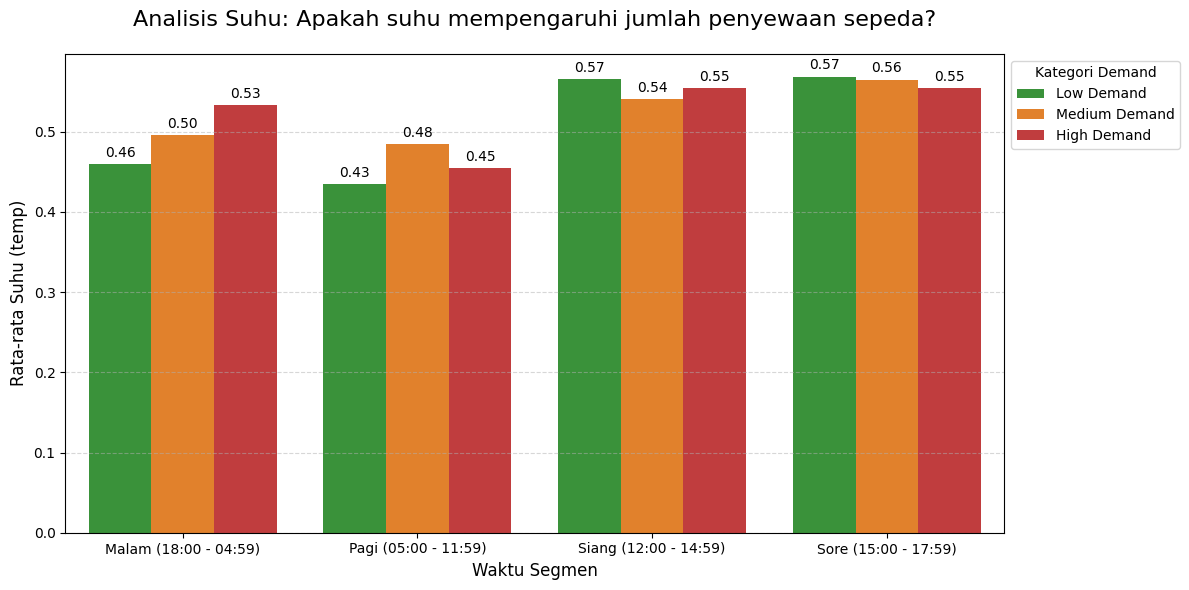

In [30]:
# --- VISUALISASI PLOT 1: SUHU (TEMP) ---
plt.figure(figsize=(12, 6))

# Grouped Bar Chart
# X = Waktu (Pagi/Siang/Sore/Malam)
# Y = Rata-rata Suhu (temp)
# Hue = Level Demand (Low/Med/High)
ax = sns.barplot(
    data=df_hour,
    x='time_segment',
    y='temp',
    hue='demand_label',
    palette={'Low Demand': '#2ca02c', 'Medium Demand': '#ff7f0e', 'High Demand': '#d62728'}, # Hijau, Orange, Merah
    errorbar=None 
)

# Dekorasi
plt.title("Analisis Suhu: Apakah suhu mempengaruhi jumlah penyewaan sepeda?", fontsize=16, pad=20)
plt.xlabel("Waktu Segmen", fontsize=12)
plt.ylabel("Rata-rata Suhu (temp)", fontsize=12)
plt.legend(title='Kategori Demand', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Label Angka di atas batang
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

Grafik di atas mengungkapkan bahwa pengaruh suhu terhadap minat bersepeda berubah tergantung waktunya:

1. Pada waktu Malam dan Pagi, semakin tinggi suhu, maka penyewaan sepeda semakin ramai. Contohnya, pada malam hari: batang merah (High Demand) memiliki suhu rata-rata tertinggi (0.53) dibandingkan saat sepi (0.46). Karena malam dan pagi biasanya dingin, maka ketika suhu sedikit lebih hangat, orang lebih nyaman untuk keluar bersepeda.

2. Pola sebaliknya terjadi di Siang dan Sore hari. Justru pada saat kondisi Sepi (Low Demand), suhunya tercatat paling tinggi (0.57). Contohnya pada siang hari, batang hijau (Low Demand) lebih tinggi daripada batang merah. Ini mengindikasikan bahwa cuaca yang terlalu panas di siang bolong justru membuat orang malas menyewa sepeda. Orang justru lebih suka menyewa saat suhu siang/sore sedikit lebih adem.

Kesimpulan: **Suhu hangat** adalah **pendorong penyewaan** di jam dingin (**Pagi/Malam**), tapi **suhu yang terlalu panas menjadi penghambat di jam terik (Siang/Sore)**.

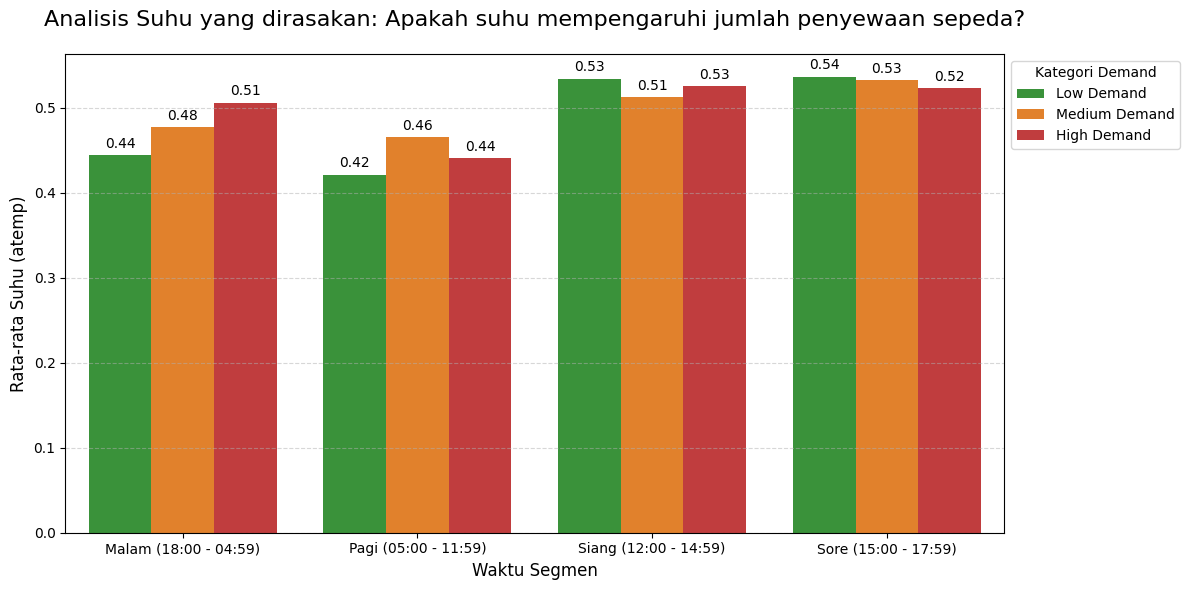

In [31]:
# --- VISUALISASI PLOT 2: SUHU (ATEMP) ---
plt.figure(figsize=(12, 6))

# Grouped Bar Chart
# X = Waktu (Pagi/Siang/Sore/Malam)
# Y = Rata-rata Suhu yang dirasakan (atemp)
# Hue = Level Demand (Low/Med/High)
ax = sns.barplot(
    data=df_hour,
    x='time_segment',
    y='atemp',
    hue='demand_label',
    palette={'Low Demand': '#2ca02c', 'Medium Demand': '#ff7f0e', 'High Demand': '#d62728'}, # Hijau, Orange, Merah
    errorbar=None 
)

# Dekorasi
plt.title("Analisis Suhu yang dirasakan: Apakah suhu mempengaruhi jumlah penyewaan sepeda?", fontsize=16, pad=20)
plt.xlabel("Waktu Segmen", fontsize=12)
plt.ylabel("Rata-rata Suhu (atemp)", fontsize=12)
plt.legend(title='Kategori Demand', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Label Angka di atas batang
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

Pola pada suhu yang dirasakan (atemp) sangat identik dengan suhu termometer (temp), menegaskan kembali preferensi penyewa sepeda terhadap kenyamanan termal:

1. **Pagi & Malam**: Di waktu dingin (Pagi/Malam), jumlah penyewaan sepeda yang tinggi (**High Demand**) justru terjadi **saat suhu yang dirasakan lebih hangat**. Orang cenderung menghindari bersepeda saat udara terasa terlalu menusuk.

2. **Siang & Sore**: Di waktu terik, jumlah penyewaan sepeda yang tinggi (**High Demand**) justru terjadi **saat suhu yang dirasakan** sedikit **lebih sejuk**. Contohnya pada segmen Sore hari, High Demand terjadi di angka 0.52, sedangkan saat Low Demand (sepi), suhu yang dirasakan justru lebih panas di angka 0.54. Ini menunjukkan bahwa rasa gerah atau kepanasan adalah faktor penghambat orang bersepeda di sore dan siang hari.

#### Apakah kelembaban mempengaruhi keputusan orang untuk menyewa sepeda di jam-jam tertentu?

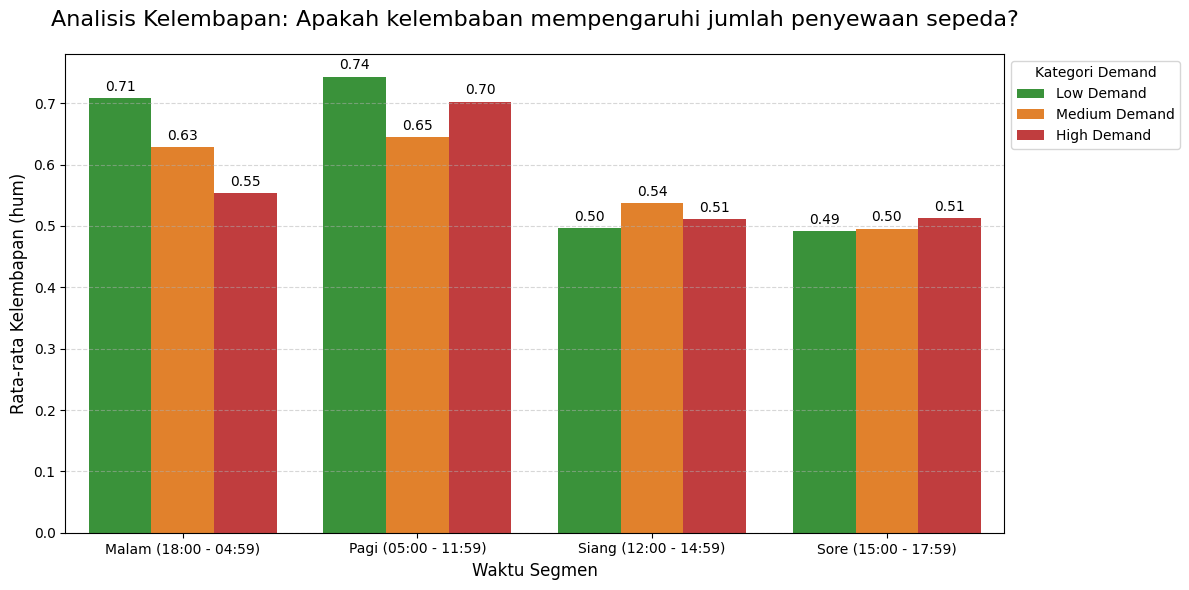

In [32]:
# --- VISUALISASI PLOT 3: KELEMBAPAN (HUM) ---
plt.figure(figsize=(12, 6))

# Grouped Bar Chart
# X = Waktu (Pagi/Siang/Sore/Malam)
# Y = Rata-rata Kelembapan (hum)
# Hue = Level Demand (Low/Med/High)
ax = sns.barplot(
    data=df_hour,
    x='time_segment',
    y='hum',
    hue='demand_label',
    palette={'Low Demand': '#2ca02c', 'Medium Demand': '#ff7f0e', 'High Demand': '#d62728'}, # Hijau, Orange, Merah
    errorbar=None 
)

# Dekorasi
plt.title("Analisis Kelembapan: Apakah kelembaban mempengaruhi jumlah penyewaan sepeda?", fontsize=16, pad=20)
plt.xlabel("Waktu Segmen", fontsize=12)
plt.ylabel("Rata-rata Kelembapan (hum)", fontsize=12)
plt.legend(title='Kategori Demand', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Menambahkan Label Angka di atas batang
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

Grafik diatas menunjukkan bahwa kelembapan udara memiliki dampak yang berbeda tergantung waktu:

1. **Pagi & Malam**: Pada waktu Malam, terlihat pola yang sangat konsisten, yaitu semakin lembap udara, maka semakin sedikit jumlah penyewaan sepeda. Low Demand (Sepi) terjadi saat kelembapan sangat tinggi (0.71), sedangkan High Demand (Ramai) terjadi saat udara jauh lebih kering (0.55). Hal serupa terjadi di Pagi hari, di mana momen paling sepi (Low Demand) memiliki kelembapan tertinggi (0.74). Ini menandakan **orang sangat menghindari bersepeda saat udara terlalu basah, berkabut, atau berembun tebal di malam/pagi** hari.

2. **Siang & Sore**: Pada siang dan sore hari, grafik cenderung rata. Angka kelembapan berkisar di 0.49 - 0.54 baik saat ramai maupun sepi. Ini menunjukkan bahwa di jam-jam produktif ini, **kelembapan bukan faktor penentu**. Perubahan kelembapan sedikit saja **tidak mempengaruhi keputusan** orang **untuk menyewa** sepeda.

Kesimpulan: **Kelembapan yang tinggi** merupakan **faktor penghambat minat penyewaan** sepeda **di malam dan pagi hari**, namun tidak terlalu dipedulikan saat siang dan sore.

#### Apakah kecepatan angin mempengaruhi keputusan orang untuk menyewa sepeda di jam-jam tertentu?

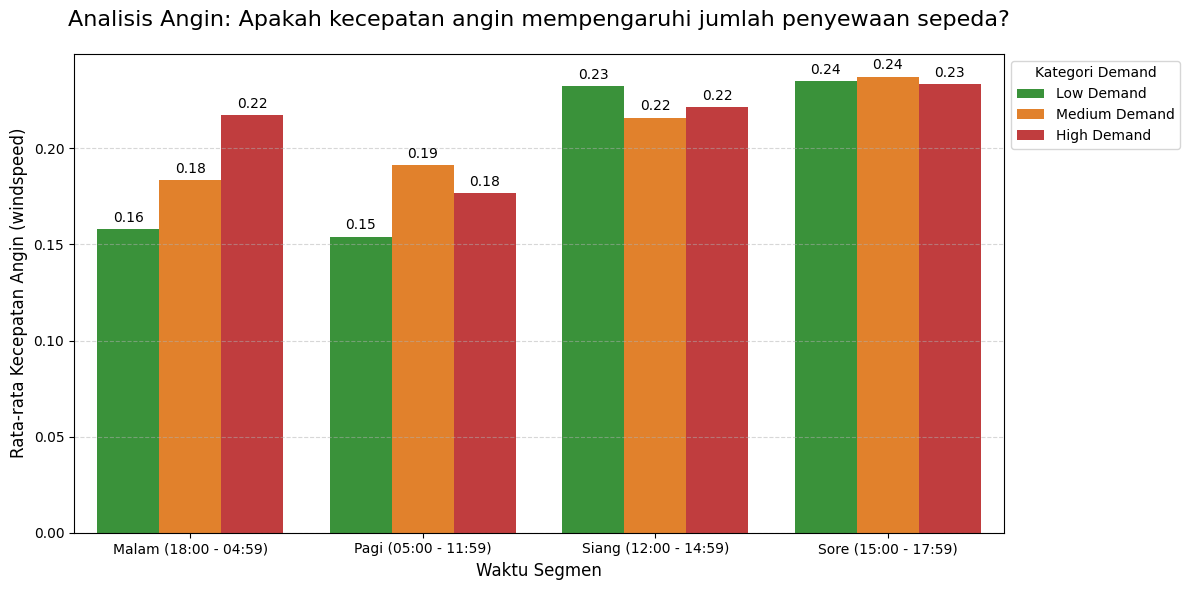

In [33]:
# --- VISUALISASI PLOT 4: KECEPATAN ANGIN (WINDSPEED) ---
plt.figure(figsize=(12, 6))

# Grouped Bar Chart
# X = Waktu (Pagi/Siang/Sore/Malam)
# Y = Rata-rata Kecepatan Angin (windspeed)
# Hue = Level Demand (Low/Med/High)
ax = sns.barplot(
    data=df_hour,
    x='time_segment',
    y='windspeed',
    hue='demand_label',
    palette={'Low Demand': '#2ca02c', 'Medium Demand': '#ff7f0e', 'High Demand': '#d62728'}, # Hijau, Orange, Merah
    errorbar=None 
)

# Dekorasi
plt.title("Analisis Angin: Apakah kecepatan angin mempengaruhi jumlah penyewaan sepeda?", fontsize=16, pad=20)
plt.xlabel("Waktu Segmen", fontsize=12)
plt.ylabel("Rata-rata Kecepatan Angin (windspeed)", fontsize=12)
plt.legend(title='Kategori Demand', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Menambahkan Label Angka di atas batang
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

Berbeda dengan faktor lainnya, **kecepatan angin tidak terbukti menjadi penghambat utama penyewaan sepeda** pada jam-jam sibuk.

1. **Pagi & Malam**
    
    Justru pada Jam High Demand (18:00-19:00), rata-rata kecepatan angin tercatat paling tinggi (0.22) dibandingkan saat Jam Low Demand yang hanya 0.16. Ini menunjukkan **orang tetap menyewa sepeda meskipun kondisi lebih berangin**. Pola serupa terlihat di pagi hari. Jam High Demand (08:00) memiliki angin yang sedikit lebih kencang (0.18) dibandingkan Jam Low Demand (05:00-06:00) yang lebih tenang (0.15).

2. **Siang & Sore**
    
    Grafik terlihat sangat rata. Kecepatan angin pada Jam High Demand (Jam 13:00 & 17:00) hampir sama persis dengan jam-jam sepi di sekitarnya (kisaran 0.22 - 0.24). Artinya, selama angin tidak badai ekstrem, **kecepatan angin tidak mempengaruhi keputusan orang untuk menyewa sepeda di siang dan sore hari**.

#### Pada Musim Apa dan Pada Jam Berapa Penyewaan Sepeda Paling Ramai? 

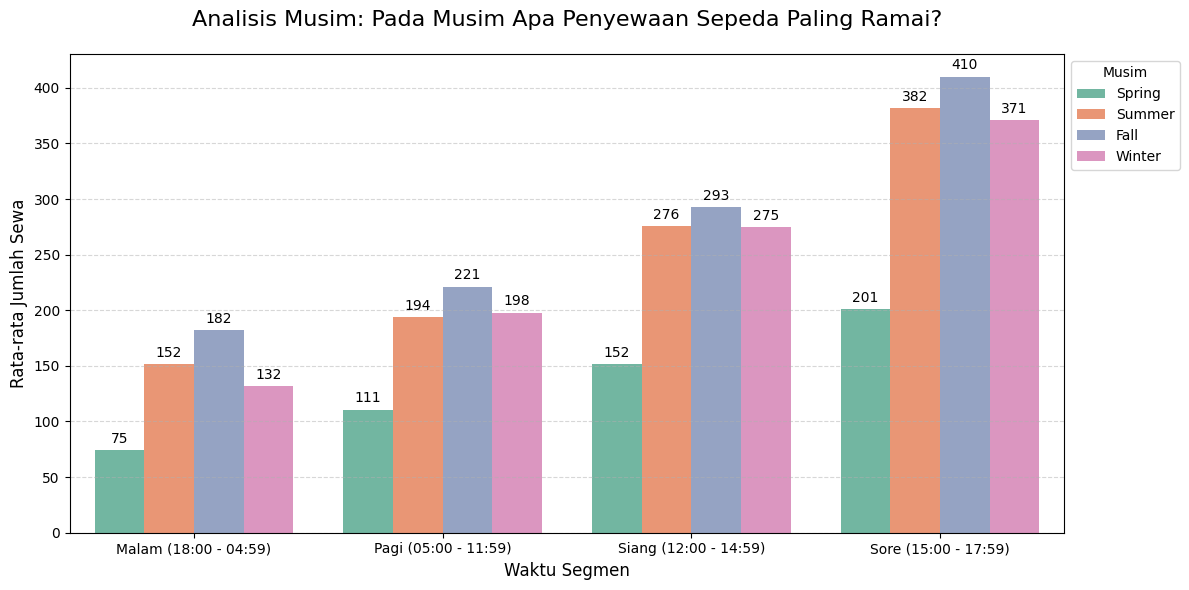

In [34]:
# --- VISUALISASI PLOT 5: MUSIM (SEASON) ---
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
df_hour['season_label'] = df_hour['season'].replace(season_map)

plt.figure(figsize=(12, 6))

# Grouped Bar Chart
# X = Waktu (Pagi/Siang/Sore/Malam)
# Y = Rata-rata Jumlah Sewa (cnt)
# Hue = Musim
ax = sns.barplot(
    data=df_hour,
    x='time_segment',
    y='cnt',
    hue='season_label',
    palette='Set2',
    errorbar=None 
)

# Dekorasi
plt.title("Analisis Musim: Pada Musim Apa Penyewaan Sepeda Paling Ramai?", fontsize=16, pad=20)
plt.xlabel("Waktu Segmen", fontsize=12)
plt.ylabel("Rata-rata Jumlah Sewa", fontsize=12)
plt.legend(title='Musim', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Menambahkan Label Angka di atas batang
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

Grafik di atas memperlihatkan bahwaa faktor musim dan waktu dalam sehari sama-sama memainkan peran penting dalam menentukan jumlah penyewaan sepeda:

1. Musim Gugur (Fall) Paling Dominan
    
    Di setiap segmen waktu, baik itu Pagi, Siang, Sore, maupun Malam, **Musim Gugur (Fall) selalu mencatat rata-rata jumlah penyewaan tertinggi**. Sebaliknya, **Musim Semi (Spring) selalu** menjadi musim yang **paling sepi** penyewa di sepanjang hari.

2. Sore Hari adalah Puncak Aktivitas Utama

    Meskipun musim memberikan pengaruh yang konsisten, **faktor jam (waktu) terbukti sangat krusial**. Terlihat bahwa **Sore hari (15:00 - 17:59)** merupakan waktu **paling ramai** secara umum pada semua musim. Sebagai contoh, pada Musim Gugur, rata-rata penyewaan memuncak tajam di angka 410 unit pada sore hari, jauh meninggalkan angka di waktu siang (293 unit) atau pagi (221 unit).

Kesimpulan: **Musim gugur adalah musim favorit** masyarakat **untuk bersepeda**, namun lonjakan drastis yang selalu terjadi pada sore hari membuktikan bahwa **jam operasional (waktu aktivitas harian) adalah faktor penentu yang sama pentingnya dengan kondisi musim** itu sendiri.

#### Pada Kondisi Cuaca Apa dan Pada Jam Berapa Penyewaan Sepeda Paling Ramai? 

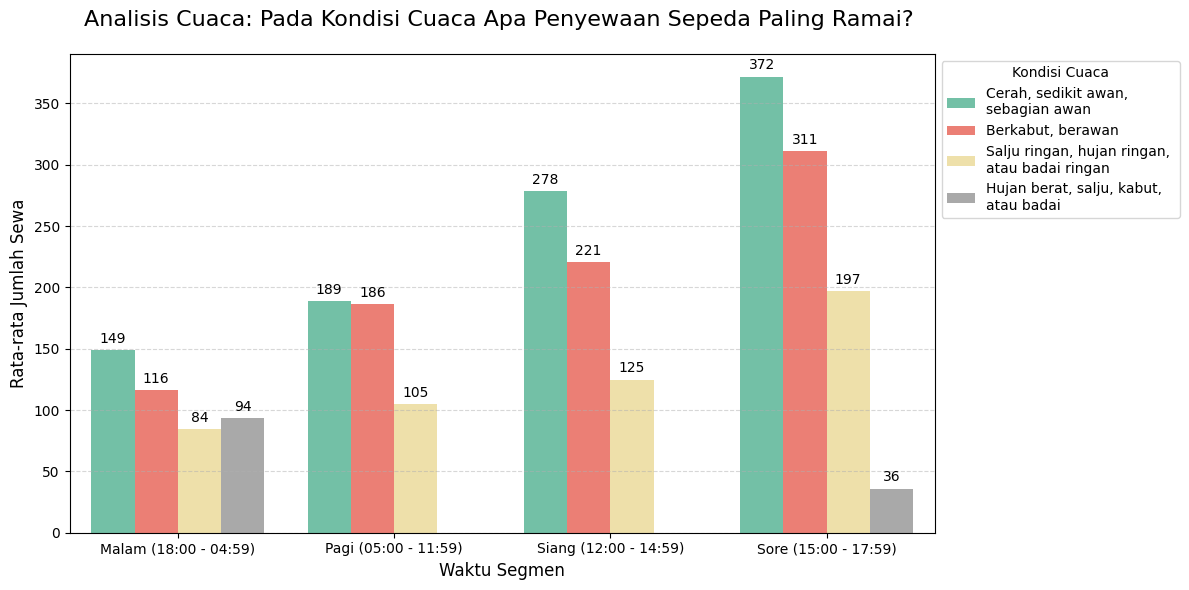

In [35]:
# --- VISUALISASI PLOT 6: KONDISI CUACA (WEATHERSIT) ---
weather_map = {
    1: "Cerah, sedikit awan, \nsebagian awan",
    2: "Berkabut, berawan",
    3: "Salju ringan, hujan ringan, \natau badai ringan",
    4: "Hujan berat, salju, kabut, \natau badai"

}
df_hour['weather_label'] = df_hour['weathersit'].replace(weather_map)

# Mengurutkan legend dari Cerah -> Cuaca Buruk
weather_order = ['Cerah, sedikit awan, \nsebagian awan', 'Berkabut, berawan', 'Salju ringan, hujan ringan, \natau badai ringan', 'Hujan berat, salju, kabut, \natau badai']

plt.figure(figsize=(12, 6))

# Grouped Bar Chart
ax = sns.barplot(
    data=df_hour,
    x='time_segment',
    y='cnt',
    hue='weather_label',
    hue_order=weather_order,
    palette=['#66CDAA', '#FF6F61', '#F9E79F', '#A9A9A9'], # Hijau cerah, merah bata, kuning pucat, abu
    errorbar=None 
)

# Dekorasi
plt.title("Analisis Cuaca: Pada Kondisi Cuaca Apa Penyewaan Sepeda Paling Ramai? ", fontsize=16, pad=20)
plt.xlabel("Waktu Segmen", fontsize=12)
plt.ylabel("Rata-rata Jumlah Sewa", fontsize=12)
plt.legend(title='Kondisi Cuaca', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Menambahkan Label Angka di atas batang
for container in ax.containers:
    # Handle error jika ada kategori cuaca yang datanya kosong
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

Berdasarkan grafik di atas, kondisi cuaca memberikan dampak penurunan yang sangat jelas terhadap jumlah penyewaan di semua segmen waktu:

1. **Cuaca Cerah Selalu Mendominasi**
    
    Pada semua waktu (Pagi, Siang, Sore, dan Malam), rata-rata penyewaan sepeda selalu mencapai angka tertinggi saat cuaca cerah, sedikit awan, sebagian awan, dan secara konsisten menurun ketika cuaca memburuk.

2. **Tidak Ada Penyewaan di Pagi dan Siang Hari saat Cuaca Ekstrem**

    Dampak paling ekstrem dari cuaca memengaruhi waktu Pagi (05:00 - 11:59) dan Siang (12:00 - 14:59). Pada kedua segmen waktu ini, tidak ada aktivitas sama sekali (rata-rata 0 penyewaan) saat terjadi hujan berat, salju, kabut, atau badai.

3. **Tetap Ada Penyewaan di Sore dan Malam Hari saat Cuaca Ekstrem**

    Berbeda dengan pagi dan siang, pada waktu Sore (15:00 - 17:59) masih tercatat rata-rata 36 penyewaan saat terjadi hujan berat, salju, kabut, atau badai. Sedangkan pada waktu Malam (18:00 - 04:59), rata-rata penyewaan saat terjadi hujan berat, salju, kabut, atau badai tercatat sebesar 94 penyewaan, angka ini bahkan sedikit lebih tinggi dibandingkan rata-rata penyewaan saat Salju ringan, hujan ringan, atau badai ringan di waktu yang sama (84 penyewaan).

## Conclusion

1. **Faktor yang Paling Mempengaruhi Jumlah Penyewaan Sepeda per Hari**

    Faktor paling dominan yang memengaruhi penyewaan sepeda secara positif adalah **suhu udara (temp & atemp)**. Kondisi cuaca yang hangat berkorelasi sangat kuat dengan tingginya minat masyarakat untuk bersepeda. **Musim gugur dan musim panas** juga turut **mendorong peningkatan volume penyewaan**. Sebaliknya, kondisi **cuaca buruk (hujan/badai) dan kecepatan angin yang tinggi merupakan faktor penghambat utama**. **Aspek kalender** seperti hari kerja, hari libur, atau akhir pekan **tidak memberikan dampak** yang berarti, menandakan bahwa layanan sepeda ini diandalkan setiap hari secara konsisten selama cuacanya mendukung.

2. **Pola Pergerakan Jumlah Penyewaan Sepeda dalam Rentang 24 Jam**
  
    Pergerakan penyewaan sepeda membentuk pola dua puncak utama (bimodal). **Titik puncak tertinggi** aktivitas harian terjadi pada **sore hari pukul 17.00**, disusul oleh **puncak kedua pada pagi hari pukul 08.00**. Aktivitas penyewaan berjalan stabil di angka menengah sepanjang siang hari, lalu mereda secara perlahan di malam hari hingga menyentuh **titik terendah pada pukul 04.00 dini hari**.

3. **Faktor Pendorong Tingginya Penyewaan pada Masing-masing Periode Waktu**

    Tingkat keramaian pada setiap segmen waktu sangat bergantung pada toleransi kenyamanan lingkungan penggunanya. Pada **pagi dan malam** hari yang cenderung dingin, **penyewaan tinggi** hanya terjadi **saat suhu terasa lebih hangat dan udara tidak lembap**. Namun pada **siang dan sore** hari, **suhu** yang terlampau **panas** justru **dihindari**, sementara kelembapan dan kecepatan angin tidak lagi menjadi hambatan. Terlepas dari waktu operasionalnya, **musim gugur dan cuaca cerah** merupakan kondisi paling ideal yang selalu **menghasilkan angka penyewaan tertinggi**. **Cuaca ekstrem melumpuhkan total aktivitas penyewaan di pagi dan siang** hari, meski sebagian kecil pengguna tetap terpaksa menerobos cuaca buruk di sore dan malam hari.

## Save the File

In [36]:
df_day.to_csv("main_data_day.csv", index=False)
df_hour.to_csv("main_data_hour.csv", index=False)